# Irregular Scenario – Fingerprint Method 1

**Scene:** Calle Esparteros (adjacent to Plaza Mayor) – a narrow, asymmetric street with 2 transmitters at z=5m. Strong NLOS conditions and multipath propagation.

**Method 1:** Fingerprint based on **channel gain only** (one value per TX in dB). Position estimation uses kNN with Euclidean distance.

This scenario tests how channel-gain-only fingerprints perform under complex propagation conditions.

## 1. Environment Setup
Install required dependencies.

In [1]:
# Celda 1: Instalar dependencias
!apt-get update
!apt-get install -y llvm
!pip install sionna-rt

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Hit:5 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4357 kB]
Fetched 4614 kB in 1s (5385 kB/s)   
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
llvm is already the newest version (1:14.0-55~exp2).
0 upgraded, 0 newly installed, 0 to remove and 114 not upgraded.


In [2]:
!pip uninstall sionna-rt -y
!pip install --upgrade pip

!pip install sionna-rt
!pip install scikit-learn


Found existing installation: sionna-rt 2.0.1
Uninstalling sionna-rt-2.0.1:
  Successfully uninstalled sionna-rt-2.0.1
  Using cached sionna_rt-2.0.1-py3-none-any.whl.metadata (4.8 kB)
Using cached sionna_rt-2.0.1-py3-none-any.whl (8.4 MB)


## 2. Library Imports
Import Sionna RT, NumPy, Matplotlib, and other required modules.

In [3]:
# después de reiniciar
import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, KFold



no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# (Aquí puedes continuar con el resto de tu código)
print("¡Sionna RT importado con éxito!")

¡Sionna RT importado con éxito!


## 3. Antenna Configuration
Define transmitter (TR38.901) and receiver (dipole, cross-polarized) antenna arrays.

In [4]:
# Configure antenna array for all transmitters
tx_array_config  = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",  #tr38901
                             polarization="V")

# Configure antenna array for all receivers
rx_array_config = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",  #dipole
                             polarization="cross") #cross

## 4. Path Solver Configuration
Set ray tracing parameters. The `max_depth` parameter is changed manually between executions to evaluate LOS, NLOS1, NLOS2, and NLOS6 conditions.

In [103]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
solver_params = dict(
                 max_depth=6, #max numero de rebotes permitidos
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

## 5. Load 3D Scene
Import the Mitsuba/Sionna scene file for the scenario.

In [104]:
scene= load_scene("Escena_Irregular_plazaMayor/Escena_Irregular_plazaMayor.xml", merge_shapes=True) # Merge shapes to speed-up computations

## 6. Transmitter Placement
Place transmitters at fixed positions in the irregular (Calle Esparteros) scenario.

In [105]:
scene.tx_array = tx_array_config
scene.rx_array = rx_array_config


np.random.seed(42) 

tx = Transmitter(name="tx",
                position=[-25, -5, 5],
                display_radius=1)
tx1 = Transmitter(name="tx1",
                 position=[-30, -30, 5],
                 display_radius=1)
tx2 = Transmitter(name="tx2",
                position=[40, 10, 10],
                display_radius=1)


# [18, -37, 26]


scene.add(tx)
scene.add(tx1)
#scene.add(tx2)



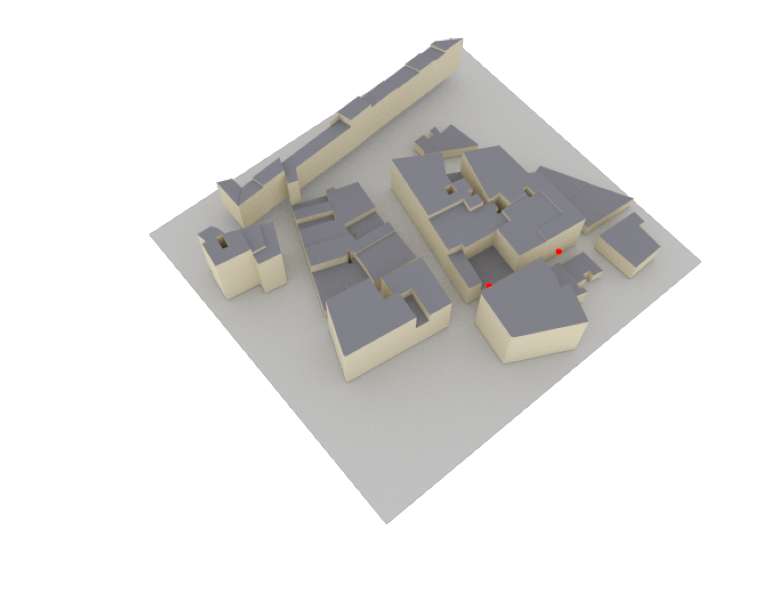

In [32]:
if not no_preview:
    scene.preview();

# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

# Create new camera with different configuration
my_cam = Camera(position=[-100,100,250], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

LA REGION DENTRO DE LA PLAZA MAYOR ESTA ACOTADA POR LOS 4 PUNTOS DE COORDENADAS: </BR>
[-50, -37, 26] </BR>
[50, -37, 26]</BR>
[-50, 37, 26]</BR>
[50, 37, 26]</BR>

[-18, -27, 20]


GRID SEARCH

Con paso_xy = 3 m:

X → 21 puntos

Y → 16 puntos

Z → 2 niveles

👉 21 × 16 × 2 = 672 receptores

Posicion 1 a estimar (0.0, 0.0, 1.5)

### GRID SEARCH. RECEPTORES TRAINING RX_GRID

## 7. Training Grid (Reference Receivers)
Create a uniform grid of receivers spaced 3m apart. These serve as the fingerprint database for position estimation.

In [106]:
import numpy as np
import mitsuba as mi
from sionna.rt import Receiver
np.random.seed(42) 
# =======================================
# Rejilla 3D con SOLO 2 niveles en Z
# =======================================
def crear_rejilla_2_niveles_z(
    scene,
    x_lim,
    y_lim,
    z_levels,
    paso_xy,
    nombre_base="rx"
):
    # Coordenadas X, Y uniformes
    x_coords = np.arange(x_lim[0], x_lim[1] + paso_xy, paso_xy)
    
    if y_lim[0] < y_lim[1]:
        y_coords = np.arange(y_lim[0], y_lim[1] + paso_xy, paso_xy)
    else:
        y_coords = np.arange(y_lim[0], y_lim[1] - paso_xy, -paso_xy)


    receptores = []
    idx = 0

    for z in z_levels:
        for x in x_coords:
            for y in y_coords:
                pos = mi.Point3f(float(x), float(y), float(z))
                rx = Receiver(
                    name=f"{nombre_base}_{idx}",
                    position=pos,
                    display_radius=0.5
                )
                scene.add(rx)
                receptores.append(rx)
                idx += 1

    return receptores

# =======================================
# Definición del espacio
# =======================================
x_lim = [-40, -10]
y_lim = [10, -40]

# SOLO DOS NIVELES EN Z
z_levels = [1.5]

paso_xy = 3.0  # separación en X e Y (metros)

# Crear receptores
receptores_grid = crear_rejilla_2_niveles_z(
    scene,
    x_lim,
    y_lim,
    z_levels,
    paso_xy,
    nombre_base="rx_grid"
)

print(f"\n✔ Receptores creados: {len(receptores_grid)}")

print("\nEjemplo de receptores:") 
for i, rx in enumerate(receptores_grid[:]):
    x, y, z = [rx.position[j].numpy().item() for j in range(3)] 
    print(f"R{i:03d}: ({x:.1f}, {y:.1f}, {z:.1f})")



✔ Receptores creados: 198

Ejemplo de receptores:
R000: (-40.0, 10.0, 1.5)
R001: (-40.0, 7.0, 1.5)
R002: (-40.0, 4.0, 1.5)
R003: (-40.0, 1.0, 1.5)
R004: (-40.0, -2.0, 1.5)
R005: (-40.0, -5.0, 1.5)
R006: (-40.0, -8.0, 1.5)
R007: (-40.0, -11.0, 1.5)
R008: (-40.0, -14.0, 1.5)
R009: (-40.0, -17.0, 1.5)
R010: (-40.0, -20.0, 1.5)
R011: (-40.0, -23.0, 1.5)
R012: (-40.0, -26.0, 1.5)
R013: (-40.0, -29.0, 1.5)
R014: (-40.0, -32.0, 1.5)
R015: (-40.0, -35.0, 1.5)
R016: (-40.0, -38.0, 1.5)
R017: (-40.0, -41.0, 1.5)
R018: (-37.0, 10.0, 1.5)
R019: (-37.0, 7.0, 1.5)
R020: (-37.0, 4.0, 1.5)
R021: (-37.0, 1.0, 1.5)
R022: (-37.0, -2.0, 1.5)
R023: (-37.0, -5.0, 1.5)
R024: (-37.0, -8.0, 1.5)
R025: (-37.0, -11.0, 1.5)
R026: (-37.0, -14.0, 1.5)
R027: (-37.0, -17.0, 1.5)
R028: (-37.0, -20.0, 1.5)
R029: (-37.0, -23.0, 1.5)
R030: (-37.0, -26.0, 1.5)
R031: (-37.0, -29.0, 1.5)
R032: (-37.0, -32.0, 1.5)
R033: (-37.0, -35.0, 1.5)
R034: (-37.0, -38.0, 1.5)
R035: (-37.0, -41.0, 1.5)
R036: (-34.0, 10.0, 1.5)
R037: (-

### RECEPTORES A ESTIMAR. RECEPTORES TESTING: RX_TEST

## 8. Test Receivers (Unknown Positions)
100 receivers at random positions within the same area. Their positions will be estimated using fingerprinting.

In [107]:
import numpy as np
import mitsuba as mi
from sionna.rt import Receiver

np.random.seed(123)

num_test_rx = 100
receptores_test = []

for i in range(num_test_rx):
    x = np.random.uniform(x_lim[0], x_lim[1])
    y = np.random.uniform(y_lim[0], y_lim[1])
    z = 1.5

    rx = Receiver(
        name=f"rx_test_{i}",
        position=mi.Point3f(float(x), float(y), float(z)),
        display_radius=0.5
    )
    scene.add(rx)
    receptores_test.append(rx)

print(f"\n✔ Receptores a estimar test creados: {len(receptores_test)}")

print("\nEjemplo de receptores:") 
for i, rx in enumerate(receptores_test[:]):
    x, y, z = [rx.position[j].numpy().item() for j in range(3)] 
    print(f"R{i:03d}: ({x:.1f}, {y:.1f}, {z:.1f})")


✔ Receptores a estimar test creados: 100

Ejemplo de receptores:
R000: (-19.1, -4.3, 1.5)
R001: (-33.2, -17.6, 1.5)
R002: (-18.4, -11.2, 1.5)
R003: (-10.6, -24.2, 1.5)
R004: (-25.6, -9.6, 1.5)
R005: (-29.7, -26.5, 1.5)
R006: (-26.8, 7.0, 1.5)
R007: (-28.1, -26.9, 1.5)
R008: (-34.5, 1.2, 1.5)
R009: (-24.1, -16.6, 1.5)
R010: (-21.0, -32.5, 1.5)
R011: (-18.3, -20.6, 1.5)
R012: (-18.3, -6.1, 1.5)
R013: (-29.1, -1.4, 1.5)
R014: (-31.2, -21.5, 1.5)
R015: (-37.2, -11.7, 1.5)
R016: (-27.1, -14.7, 1.5)
R017: (-27.2, -5.6, 1.5)
R018: (-27.2, -34.7, 1.5)
R019: (-11.7, -15.1, 1.5)
R020: (-21.3, 4.2, 1.5)
R021: (-30.5, -10.7, 1.5)
R022: (-14.0, -2.5, 1.5)
R023: (-25.5, -39.3, 1.5)
R024: (-24.4, -20.6, 1.5)
R025: (-36.4, -31.3, 1.5)
R026: (-21.9, -17.3, 1.5)
R027: (-29.7, -5.2, 1.5)
R028: (-27.5, -24.1, 1.5)
R029: (-13.7, -15.5, 1.5)
R030: (-19.9, -19.3, 1.5)
R031: (-21.3, -23.7, 1.5)
R032: (-14.7, 5.8, 1.5)
R033: (-17.1, -2.2, 1.5)
R034: (-34.2, -18.6, 1.5)
R035: (-37.1, -34.3, 1.5)
R036: (-21.2, 

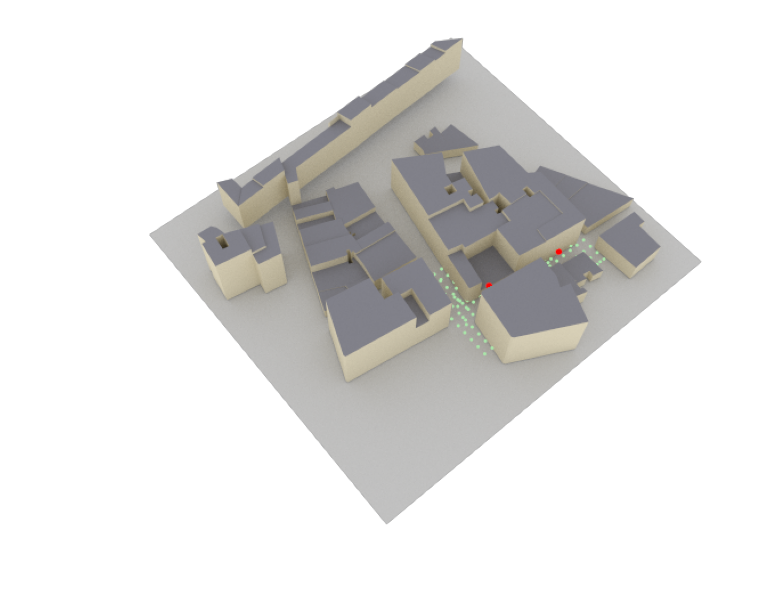

In [35]:
if not no_preview:
    scene.preview();

# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

# Create new camera with different configuration
my_cam = Camera(position=[-100,100,250], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

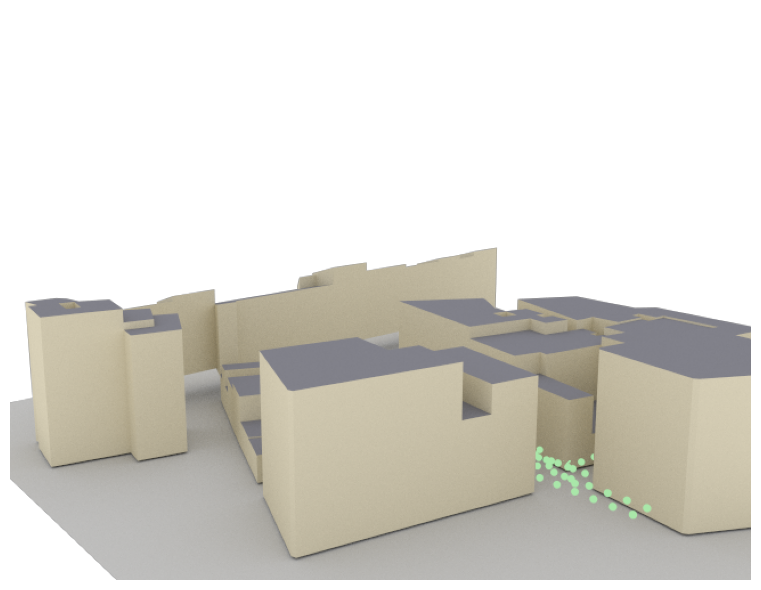

In [36]:
if not no_preview:
    scene.preview();

# Only availabe if a preview is open
if not no_preview:
    scene.render(camera="preview", num_samples=512);

# Only availabe if a preview is open
if not no_preview:
    scene.render_to_file(camera="preview",
                         filename="scene.png",
                         resolution=[650,500]);

# Create new camera with different configuration
my_cam = Camera(position=[-100,100,50], look_at=[-15,30,28])

# Render scene with new camera*
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512); # Increase num_samples to increase image quality

## 9. Run Ray Tracing
Compute all propagation paths between transmitters and receivers.

In [108]:
paths_scene_caso1 = p_solver(scene=scene, **solver_params)

## 10. Extract Channel Impulse Response (CIR)
Obtain complex channel coefficients `a` and delays `tau` for all TX-RX pairs.

In [109]:
#CIR 
#CASO 1
a_c1, tau_c1 = paths_scene_caso1.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a_c1.shape)
num_paths_c1 = a_c1.shape[4]
print("Num of possible paths from tx to rx: ", num_paths_c1)
# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau_c1.shape)



Shape of a:  (298, 2, 2, 1, 126, 1)
Num of possible paths from tx to rx:  126
Shape of tau:  (298, 2, 2, 1, 126)


FINGERPRINTS DE TRAINING, DEL GRID SEARCH RX 

## 11. Generate Training Fingerprints
For each grid receiver, compute the channel gain (in dB) from each transmitter. This forms the fingerprint vector.

In [110]:
fingerprints_grid = []
positions_grid = []

for rx_index, rx in enumerate(receptores_grid):
    fp_rx = []
    for tx_index in range(a_c1.shape[2]):
        a_rt = a_c1[rx_index, 0, tx_index, 0, :, 0]
        channel_gain = np.sum(np.abs(a_rt)**2)
        fp_rx.append(10 * np.log10(channel_gain + 1e-12))
    fingerprints_grid.append(fp_rx)
    positions_grid.append(np.array(rx.position))

fingerprints_grid = np.array(fingerprints_grid)
positions_grid = np.array(positions_grid)

print(fingerprints_grid)


[[ -97.87506   -88.03794 ]
 [ -98.61139   -86.81221 ]
 [ -92.69077   -83.64792 ]
 [ -85.464775  -83.01319 ]
 [ -90.10285   -84.16518 ]
 [ -86.55533   -83.21328 ]
 [ -84.84285   -81.97673 ]
 [ -87.476776  -80.80604 ]
 [ -91.243225  -82.673004]
 [ -95.77611   -77.37975 ]
 [ -96.505264  -77.605675]
 [ -97.87098   -76.69537 ]
 [-106.46897   -73.25131 ]
 [-109.86128   -68.31901 ]
 [-104.49528   -69.8997  ]
 [-104.44621   -77.917816]
 [-109.52115   -78.52117 ]
 [ -97.89818   -78.98684 ]
 [ -90.98443   -90.37866 ]
 [ -96.3909    -89.62413 ]
 [ -88.327484  -85.24812 ]
 [ -86.187805  -84.36969 ]
 [ -84.63767   -85.37151 ]
 [ -86.105     -84.226166]
 [ -86.71119   -82.30971 ]
 [ -86.52824   -80.11227 ]
 [ -90.979706  -78.99632 ]
 [ -93.71255   -79.38208 ]
 [ -97.07734   -76.11093 ]
 [ -98.45734   -72.04401 ]
 [ -94.142395  -74.68437 ]
 [ -98.87904   -67.22688 ]
 [ -99.81545   -70.86073 ]
 [-101.372986  -80.340416]
 [-101.05      -77.85557 ]
 [ -95.18733   -76.71056 ]
 [ -92.59424   -92.2633  ]
 

INGERPRINTS DE TESTING, DE LOS 100 RX A ESTIMAR POSICION

## 12. Generate Test Fingerprints
Same process for test receivers. Note: `offset` is used to access the correct indices in the path array.

In [111]:
fingerprints_test = []
positions_test = []

offset = len(receptores_grid)

for i, rx in enumerate(receptores_test):
    rx_index = offset + i
    fp_rx = []
    for tx_index in range(a_c1.shape[2]):
        a_rt = a_c1[rx_index, 0, tx_index, 0, :, 0]
        channel_gain = np.sum(np.abs(a_rt)**2)
        fp_rx.append(10 * np.log10(channel_gain + 1e-12))
    fingerprints_test.append(fp_rx)
    positions_test.append(np.array(rx.position))

fingerprints_test = np.array(fingerprints_test)
positions_test = np.array(positions_test)

print(fingerprints_test)

[[ -85.703125  -82.574394]
 [ -99.034035  -80.10455 ]
 [ -96.58235   -81.41484 ]
 [-113.145836  -70.17417 ]
 [ -96.168076  -94.93126 ]
 [ -93.23894   -64.782295]
 [ -84.581665  -80.691795]
 [ -92.2227    -67.32909 ]
 [ -90.55335   -86.50077 ]
 [ -98.099884  -80.975105]
 [ -94.01282   -62.67076 ]
 [ -90.82518   -68.630905]
 [ -86.464554  -84.56213 ]
 [ -82.96439   -76.45874 ]
 [ -89.63871   -68.16512 ]
 [ -87.03702   -79.177895]
 [ -89.964966  -74.16876 ]
 [ -92.875275  -76.07604 ]
 [ -94.39743   -69.18623 ]
 [ -86.23465   -90.79747 ]
 [ -89.23303   -87.424255]
 [ -84.97418   -73.77566 ]
 [ -86.59114   -88.39531 ]
 [ -93.61212   -75.95615 ]
 [ -93.1089    -74.26184 ]
 [-101.559784  -79.968925]
 [ -96.458206  -77.12831 ]
 [ -82.76944   -76.03885 ]
 [ -94.87738   -74.993065]
 [ -87.04083   -84.81423 ]
 [ -98.42946   -71.75199 ]
 [ -99.77704   -65.60232 ]
 [ -83.01327   -94.436424]
 [ -82.626656  -89.21704 ]
 [ -94.5343    -74.29413 ]
 [-101.00401   -77.15863 ]
 [ -97.12152   -62.92392 ]
 

Ejecucion de 100 test 

## LOS

## 13. Position Estimation (kNN) & Results
Estimate positions using k-Nearest Neighbors. Compare fingerprint distances, select k closest matches, and average their positions. Results shown as CDF and Mean/Median error plots.

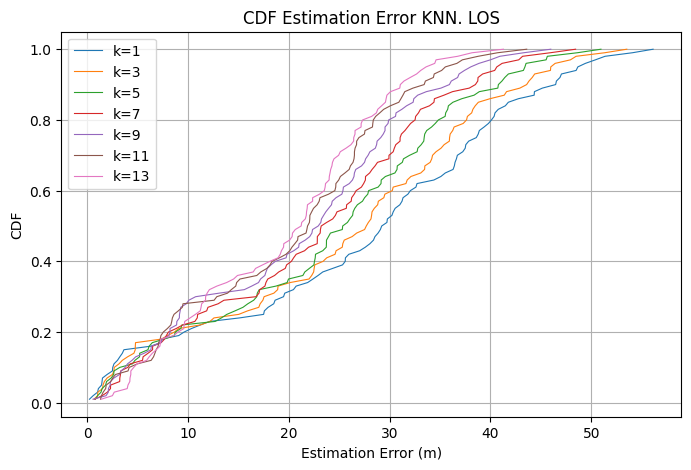

In [73]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)

# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))

# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. LOS")
plt.grid(True)
plt.legend()
plt.show()




In [74]:
errores = np.array(errores)

print("===== RESULTS =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")

===== RESULTS =====
Mean Error: 19.320 m
Median Error: 21.245 m
Maximum Error: 41.284 m
Minimum Error: 1.380 m


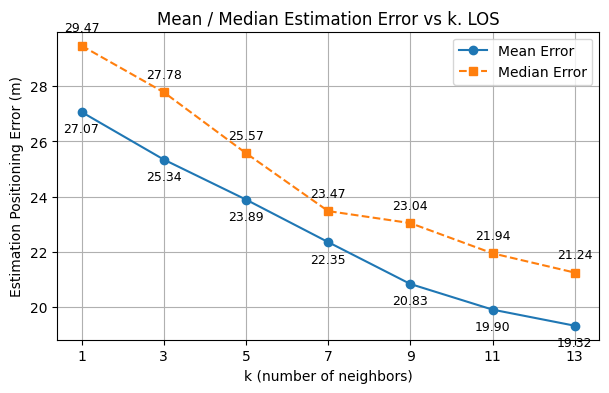

In [77]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Etiquetas numéricas Mean → abajo del punto
for k, err in zip(ks, mean_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, -15),   # separación abajo
        ha='center',
        fontsize=9
    )

# Etiquetas numéricas Median → arriba del punto
for k, err in zip(ks, median_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, 10),   # separación arriba
        ha='center',
        fontsize=9
    )

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. LOS")
plt.grid(True)
plt.legend()

# Forzar eje X con k impares
plt.xticks(range(1, 14, 2))

plt.show()

NLOS1

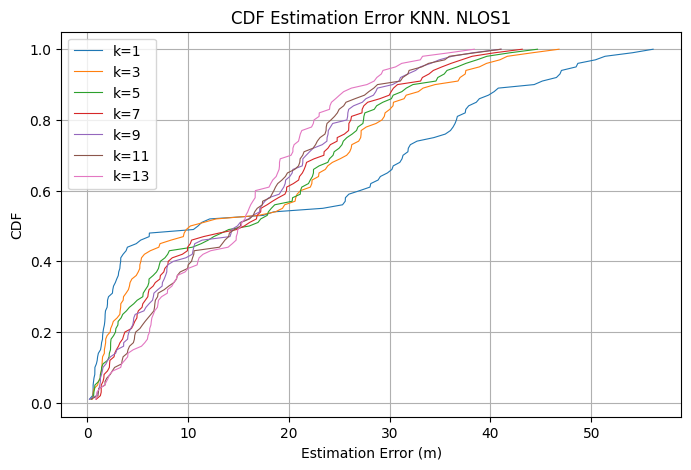

In [87]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS1")
plt.grid(True)
plt.legend()
plt.show()

In [88]:
errores = np.array(errores)

print("===== RESULTS =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")

===== RESULTS =====
Mean Error: 14.921 m
Median Error: 15.306 m
Maximum Error: 38.397 m
Minimum Error: 0.831 m


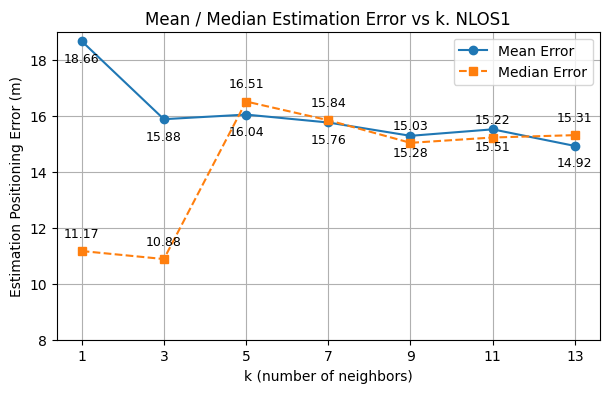

In [90]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Mean → abajo del punto
for k, err in zip(ks, mean_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, -15),   # abajo
        ha='center',
        fontsize=9
    )

# Median → arriba del punto
for k, err in zip(ks, median_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, 10),    # arriba
        ha='center',
        fontsize=9
    )

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS1")
plt.grid(True)
plt.legend()

# Forzar eje X con k impares
plt.xticks(range(1, 14, 2))

# Fijar límites eje Y
plt.ylim(8, 19)

plt.show()

NLOS2

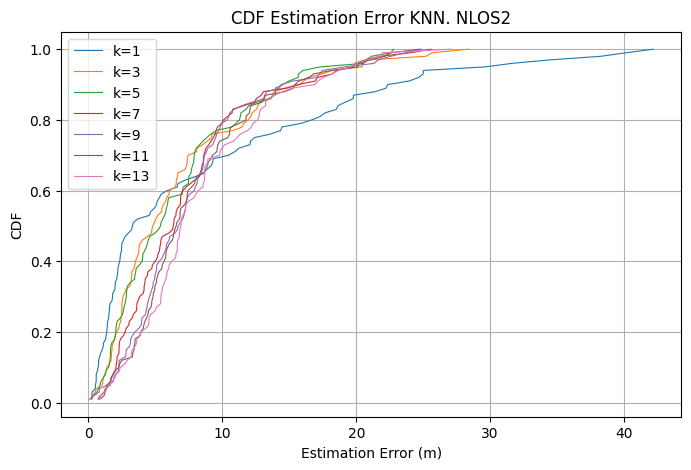

In [100]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS2")
plt.grid(True)
plt.legend()
plt.show()


In [101]:
errores = np.array(errores)

print("===== RESULTS =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")

===== RESULTS =====
Mean Error: 8.396 m
Median Error: 6.909 m
Maximum Error: 27.048 m
Minimum Error: 0.820 m


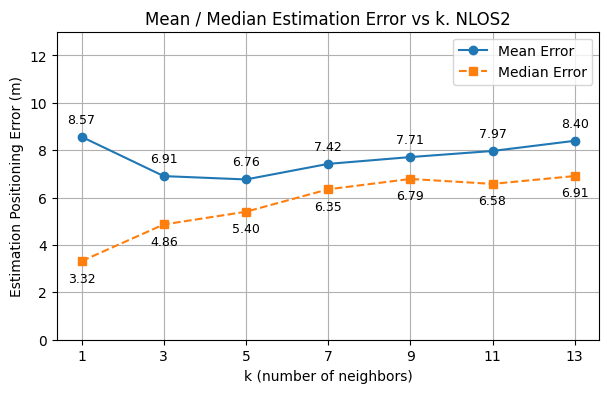

In [102]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Etiquetas numéricas Mean → arriba del punto
for k, err in zip(ks, mean_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, 10),   # desplazamiento vertical arriba
        ha='center',
        fontsize=9
    )

# Etiquetas numéricas Median → abajo del punto
for k, err in zip(ks, median_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, -15),   # desplazamiento vertical abajo
        ha='center',
        fontsize=9
    )

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS2")
plt.grid(True)
plt.legend()

# Forzar eje X con k impares
plt.xticks(range(1, 14, 2))

# Fijar límites eje Y
plt.ylim(0, 13)

plt.show()

NLOS6

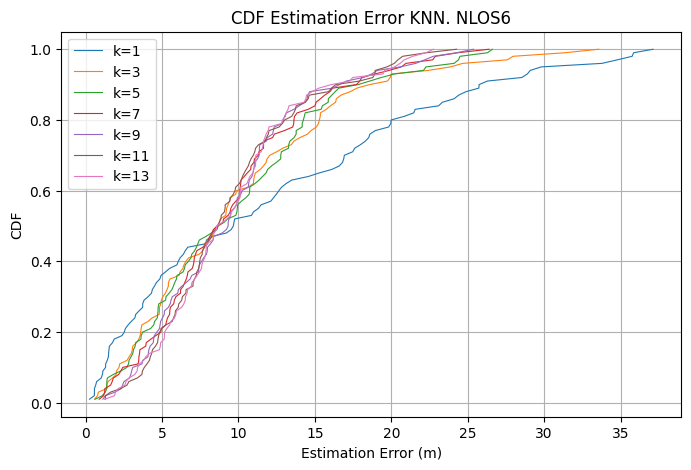

In [112]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(123)
# Lista de k a probar
ks = [1, 3, 5, 7, 9, 11, 13]

# Lista para almacenar errores para cada k
errores_por_k = {k: [] for k in ks}

# Número de receptores de prueba
num_test_rx = len(fingerprints_test)

# Función KNN para estimación de posición
def knn_estimate(query_fp, X_train, Y_train, k):
    distancias = np.linalg.norm(X_train - query_fp, axis=1)
    idx_knn = np.argsort(distancias)[:k]
    pos_est = np.mean(Y_train[idx_knn], axis=0)
    return pos_est

# =========================
# Calcular errores para todos los k
# =========================
for i in range(num_test_rx):
    query_fp = fingerprints_test[i]
    query_pos = positions_test[i]
    
    for k in ks:
        pos_est = knn_estimate(query_fp, fingerprints_grid, positions_grid, k)
        error = np.linalg.norm(pos_est - query_pos)
        errores_por_k[k].append(error)
# ===============================
# Error medio y mediana por k
# ===============================
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))
# =========================
# Crear la gráfica CDF
# =========================
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.array(errores_por_k[k])
    sorted_errores = np.sort(errores)
    cdf = np.arange(1, len(sorted_errores)+1) / len(sorted_errores)
    plt.plot(sorted_errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS6")
plt.grid(True)
plt.legend()
plt.show()


In [113]:
errores = np.array(errores)

print("===== RESULTS =====")
print(f"Mean Error: {np.mean(errores):.3f} m")
print(f"Median Error: {np.median(errores):.3f} m")
print(f"Maximum Error: {np.max(errores):.3f} m")
print(f"Minimum Error: {np.min(errores):.3f} m")

===== RESULTS =====
Mean Error: 9.533 m
Median Error: 8.760 m
Maximum Error: 22.758 m
Minimum Error: 1.260 m


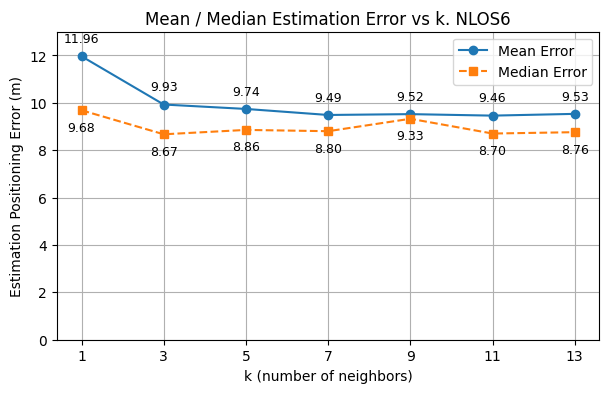

In [114]:
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s', linestyle='--', label="Median Error")

# Etiquetas numéricas Mean → arriba del punto
for k, err in zip(ks, mean_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, 10),   # desplazamiento vertical arriba
        ha='center',
        fontsize=9
    )

# Etiquetas numéricas Median → abajo del punto
for k, err in zip(ks, median_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, -15),   # desplazamiento vertical abajo
        ha='center',
        fontsize=9
    )

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS6")
plt.grid(True)
plt.legend()

# Forzar eje X con k impares
plt.xticks(range(1, 14, 2))

# Fijar límites eje Y
plt.ylim(0, 13)

plt.show()